<a href="https://colab.research.google.com/github/anjanarajan0803-max/Course/blob/master/Finex_Cost_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import basic libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset

df_raw = pd.read_csv("fraudTest.csv")

# Create a working copy
df = df_raw.copy()

# Display basic information
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (116581, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0.0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0.0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0.0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0.0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0.0


In [3]:
# Check column names and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116581 entries, 0 to 116580
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             116581 non-null  int64  
 1   trans_date_trans_time  116581 non-null  object 
 2   cc_num                 116581 non-null  int64  
 3   merchant               116581 non-null  object 
 4   category               116581 non-null  object 
 5   amt                    116581 non-null  float64
 6   first                  116581 non-null  object 
 7   last                   116581 non-null  object 
 8   gender                 116581 non-null  object 
 9   street                 116581 non-null  object 
 10  city                   116581 non-null  object 
 11  state                  116581 non-null  object 
 12  zip                    116581 non-null  int64  
 13  lat                    116581 non-null  float64
 14  long                   116581 non-nu

In [4]:
# Check missing values

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0
is_fraud,1
merch_long,1


In [5]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [6]:
# Check target variable distribution

target_counts = df['is_fraud'].value_counts()
target_percentage = df['is_fraud'].value_counts(normalize=True) * 100

print("Target Counts:")
print(target_counts)

print("\nTarget Percentage:")
print(target_percentage)

Target Counts:
is_fraud
0.0    116125
1.0       455
Name: count, dtype: int64

Target Percentage:
is_fraud
0.0    99.60971
1.0     0.39029
Name: proportion, dtype: float64


The dataset contains transaction-level information for fraud detection. Each row represents a transaction, and the target variable is 'is_fraud', where 1 indicates a fraudulent transaction and 0 indicates a genuine transaction.

The dataset is highly imbalanced. Fraudulent transactions form only a very small percentage of the total transactions. Therefore, accuracy will not be used as the primary evaluation metric. The focus will be on fraud recall, precision, F1-score, PR-AUC, and confusion matrix because the business objective is to correctly identify fraudulent transactions and reduce financial loss for the bank.

**Data Understanding + EDA**

**1. Business Problem Understanding**

# Fraud Detection System for Finex

Finex wants to build a fraud detection model to identify fraudulent card transactions. Currently, the bank bears the full cost of every fraudulent transaction. After deploying the model, transactions predicted as fraudulent will go through a second layer of authentication.

Since fraudulent transactions are very rare compared to genuine transactions, this is an imbalanced classification problem. Therefore, accuracy alone is not a reliable evaluation metric. The model will be evaluated mainly using fraud recall, precision, F1-score, PR-AUC, confusion matrix, and business savings.

The final goal is to choose a model that detects as many fraudulent transactions as possible while also reducing the financial loss for the bank.

**2. Import Libraries**

In [8]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

**3. Load Dataset Safely**

In [9]:
# Load the dataset
df_raw = pd.read_csv("fraudTest.csv")

# Create a working copy
df = df_raw.copy()

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


**4. Data Understanding**

In [10]:
# Check data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [11]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,555719.0,2.778590e+05,1.604224e+05,0.000000e+00,1.389295e+05,2.778590e+05,4.167885e+05,5.557180e+05
cc_num,555719.0,4.178387e+17,1.309837e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.635331e+15,4.992346e+18
amt,555719.0,6.939281e+01,1.567459e+02,1.000000e+00,9.630000e+00,4.729000e+01,8.301000e+01,2.276811e+04
zip,555719.0,4.884263e+04,2.685528e+04,1.257000e+03,2.629200e+04,4.817400e+04,7.201100e+04,9.992100e+04
lat,555719.0,3.854325e+01,5.061336e+00,2.002710e+01,3.466890e+01,3.937160e+01,4.189480e+01,6.568990e+01
long,555719.0,-9.023133e+01,1.372178e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.017520e+01,-6.795030e+01
city_pop,555719.0,8.822189e+04,3.003909e+05,2.300000e+01,7.410000e+02,2.408000e+03,1.968500e+04,2.906700e+06
unix_time,555719.0,1.380679e+09,5.201104e+06,1.371817e+09,1.376029e+09,1.380762e+09,1.385867e+09,1.388534e+09
merch_lat,555719.0,3.854280e+01,5.095829e+00,1.902742e+01,3.475530e+01,3.937659e+01,4.195416e+01,6.667930e+01
merch_long,555719.0,-9.023138e+01,1.373307e+01,-1.666716e+02,-9.690513e+01,-8.744520e+01,-8.026464e+01,-6.695203e+01


In [12]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Total missing values:", missing_values.sum())
missing_values[missing_values > 0]

Total missing values: 0


,0


In [13]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
# Target variable distribution
target_counts = df['is_fraud'].value_counts()
target_percentage = df['is_fraud'].value_counts(normalize=True) * 100

print("Target Counts:")
print(target_counts)

print("\nTarget Percentage:")
print(target_percentage)

Target Counts:
is_fraud
0    553574
1      2145
Name: count, dtype: int64

Target Percentage:
is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64


The dataset contains transaction-level information with 'is_fraud' as the target variable. There are no missing values and no duplicate rows in the dataset.

The target variable is highly imbalanced. Fraudulent transactions form only a very small percentage of the total transactions. Therefore, accuracy will not be treated as the primary model evaluation metric. The model will be evaluated using recall, precision, F1-score, PR-AUC, and confusion matrix, with special focus on identifying fraudulent transactions.

**5. Convert Date Columns and Create Time Features**

In [15]:
# Convert date columns to datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# Create date and time related features
df['trans_year'] = df['trans_date_trans_time'].dt.year
df['trans_month'] = df['trans_date_trans_time'].dt.month
df['trans_day'] = df['trans_date_trans_time'].dt.day
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.dayofweek

# Create age feature
df['age'] = df['trans_year'] - df['dob'].dt.year

# Check date range
print("Start date:", df['trans_date_trans_time'].min())
print("End date:", df['trans_date_trans_time'].max())
print("Number of months:", df['trans_date_trans_time'].dt.to_period('M').nunique())

Start date: 2020-06-21 12:14:25
End date: 2020-12-31 23:59:34
Number of months: 7


The transaction date column was converted into datetime format. New time-based features such as transaction month, day, hour, and day of week were created. These features can help identify whether fraudulent activity is concentrated during specific time periods. The date of birth column was used to create an age feature, which is more useful for modelling than using date of birth directly.

**6. Class Imbalance Plot**

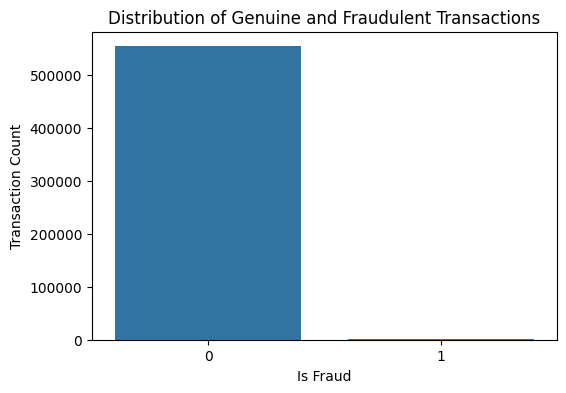

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)
plt.title("Distribution of Genuine and Fraudulent Transactions")
plt.xlabel("Is Fraud")
plt.ylabel("Transaction Count")
plt.show()

In [17]:
fraud_percentage = df['is_fraud'].value_counts(normalize=True) * 100
fraud_percentage

,proportion
is_fraud,
0,99.614014
1,0.385986


The data is highly imbalanced. Genuine transactions form more than 99% of the dataset, while fraudulent transactions form less than 1%. This means a model can achieve high accuracy by predicting almost every transaction as genuine. Hence, accuracy is misleading for this business problem. The focus should be on correctly identifying fraudulent transactions using recall, precision, F1-score, and PR-AUC.

**7. Transaction Amount Analysis**

In [19]:
# Compare amount statistics for genuine and fraudulent transactions
df.groupby('is_fraud')['amt'].agg(['count', 'mean', 'median', 'min', 'max'])

,count,mean,median,min,max
is_fraud,,,,,
0,553574,67.614408,47.15,1.00,22768.11
1,2145,528.356494,371.94,1.78,1320.92


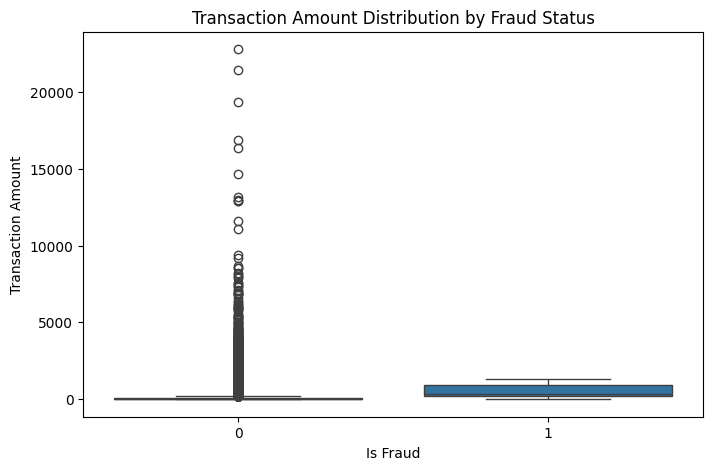

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("Is Fraud")
plt.ylabel("Transaction Amount")
plt.show()

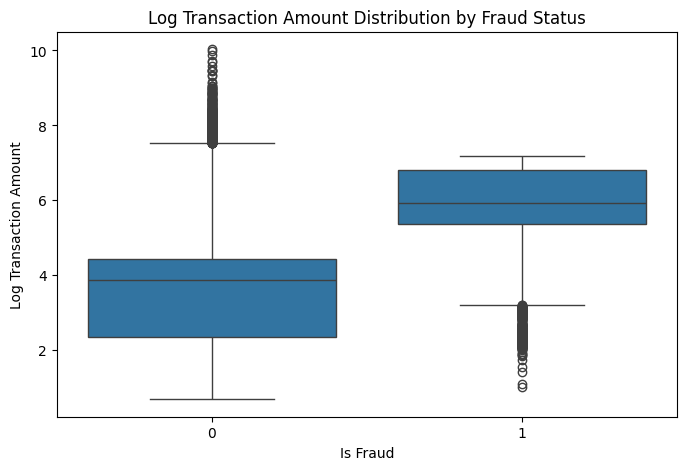

In [21]:
df['log_amt'] = np.log1p(df['amt'])

plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y='log_amt', data=df)
plt.title("Log Transaction Amount Distribution by Fraud Status")
plt.xlabel("Is Fraud")
plt.ylabel("Log Transaction Amount")
plt.show()

Fraudulent transactions have a much higher average transaction amount compared to genuine transactions. The transaction amount variable is highly skewed because most transactions are small, while a few transactions have very large values. A log-transformed amount feature was created to reduce skewness and make the variable more suitable for modelling.

**8. Fraud by Category**

In [22]:
category_fraud = (
    df.groupby('category')
    .agg(
        total_transactions=('is_fraud', 'count'),
        fraud_transactions=('is_fraud', 'sum'),
        fraud_rate=('is_fraud', 'mean'),
        average_amount=('amt', 'mean')
    )
    .reset_index()
)

category_fraud['fraud_rate_percent'] = category_fraud['fraud_rate'] * 100
category_fraud = category_fraud.sort_values(by='fraud_rate_percent', ascending=False)

category_fraud

,category,total_transactions,fraud_transactions,fraud_rate,average_amount,fraud_rate_percent
11,shopping_net,41779,506,0.012111,83.481653,1.211135
8,misc_net,27367,267,0.009756,78.600237,0.975628
4,grocery_pos,52553,485,0.009229,115.885327,0.922878
12,shopping_pos,49791,213,0.004278,76.862457,0.427788
2,gas_transport,56370,154,0.002732,63.577001,0.273195
13,travel,17449,40,0.002292,112.389683,0.229239
3,grocery_net,19426,41,0.002111,53.731667,0.211057
9,misc_pos,34574,72,0.002082,62.182246,0.208249
10,personal_care,39327,70,0.001780,48.233021,0.177995
0,entertainment,40104,59,0.001471,63.984840,0.147117


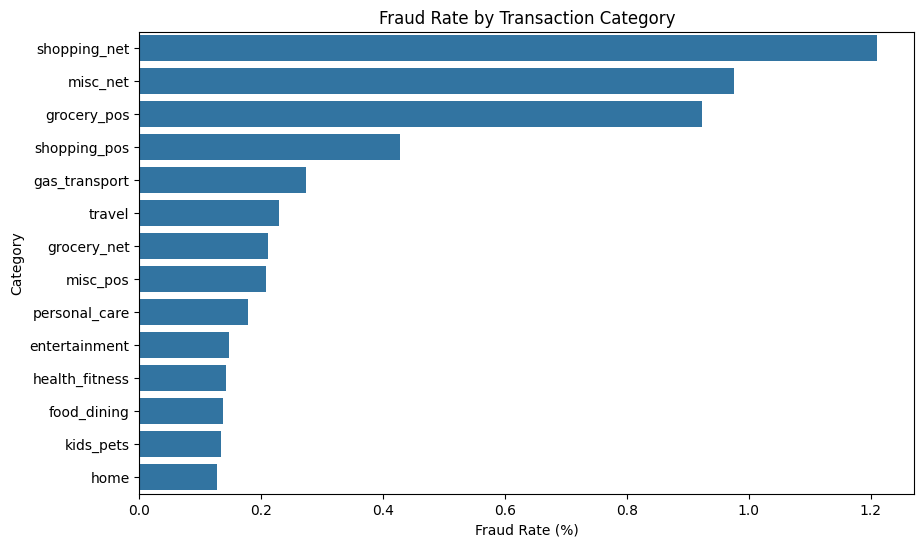

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='fraud_rate_percent',
    y='category',
    data=category_fraud
)
plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Category")
plt.show()

Fraud rates are not equal across all transaction categories. Certain categories such as online shopping, miscellaneous online transactions, and grocery point-of-sale transactions show higher fraud rates compared to other categories. This indicates that transaction category is an important predictor for fraud detection.

**9. Fraud by Transaction Hour**

In [24]:
hourly_fraud = (
    df.groupby('trans_hour')
    .agg(
        total_transactions=('is_fraud', 'count'),
        fraud_transactions=('is_fraud', 'sum'),
        fraud_rate=('is_fraud', 'mean')
    )
    .reset_index()
)

hourly_fraud['fraud_rate_percent'] = hourly_fraud['fraud_rate'] * 100
hourly_fraud

,trans_hour,total_transactions,fraud_transactions,fraud_rate,fraud_rate_percent
0,0,18153,188,0.010356,1.035641
1,1,18461,169,0.009154,0.915443
2,2,18140,168,0.009261,0.926130
3,3,18199,194,0.010660,1.065993
4,4,18075,15,0.000830,0.082988
5,5,17917,20,0.001116,0.111626
6,6,18106,14,0.000773,0.077322
7,7,18098,16,0.000884,0.088408
8,8,17993,10,0.000556,0.055577
9,9,18046,14,0.000776,0.077580


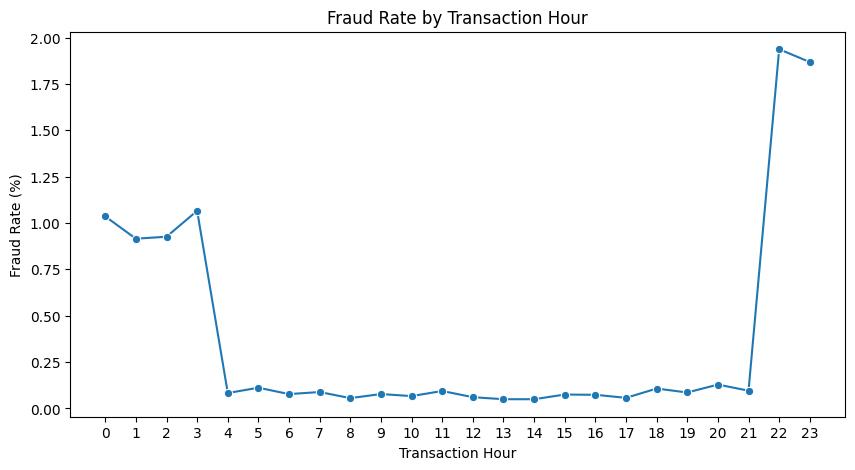

In [25]:
plt.figure(figsize=(10,5))
sns.lineplot(x='trans_hour', y='fraud_rate_percent', data=hourly_fraud, marker='o')
plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0,24))
plt.show()

Fraud activity shows variation by transaction hour. Certain late-night or early-morning hours show a higher fraud rate compared to normal transaction hours. This suggests that transaction timing can be a useful feature for detecting suspicious activity.

**10. Skewness Check**

In [26]:
# Check skewness of numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

skewness = df[numeric_cols].skew().sort_values(ascending=False)
skewness

,0
amt,3.713408e+01
is_fraud,1.600255e+01
city_pop,5.583415e+00
cc_num,2.849204e+00
age,6.079226e-01
trans_dayofweek,2.097887e-01
zip,7.724601e-02
trans_year,0.000000e+00
Unnamed: 0,-1.206865e-15
unix_time,-7.740538e-02


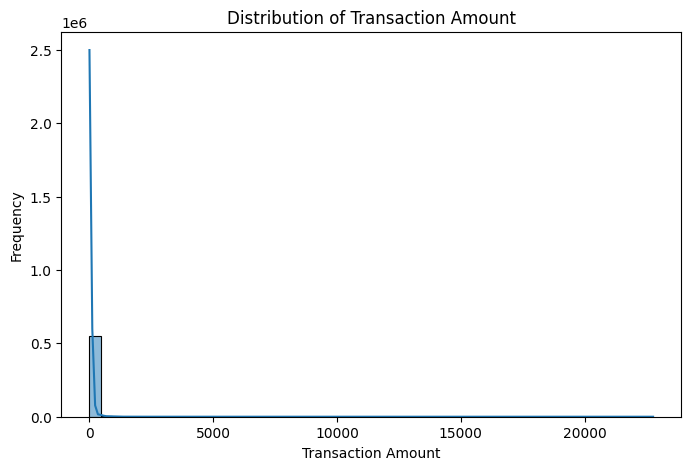

In [27]:
# Visualise skewed amount column
plt.figure(figsize=(8,5))
sns.histplot(df['amt'], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

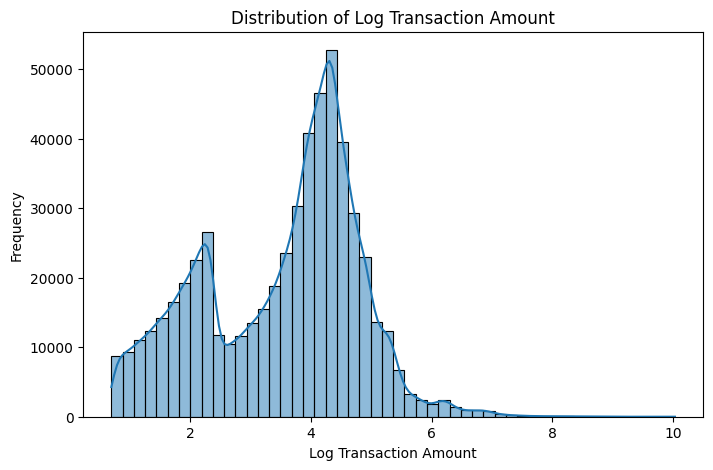

In [28]:
# Visualise log-transformed amount
plt.figure(figsize=(8,5))
sns.histplot(df['log_amt'], bins=50, kde=True)
plt.title("Distribution of Log Transaction Amount")
plt.xlabel("Log Transaction Amount")
plt.ylabel("Frequency")
plt.show()

The transaction amount variable is highly right-skewed. To reduce the effect of extreme values, a log transformation was applied using `log1p`. The transformed feature has a more balanced distribution and can help improve model performance, especially for linear models.

**11. Create Distance Feature**

In [29]:
# Function to calculate distance between customer and merchant location

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometres

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df['distance_km'] = haversine_distance(
    df['lat'],
    df['long'],
    df['merch_lat'],
    df['merch_long']
)

df[['lat', 'long', 'merch_lat', 'merch_long', 'distance_km']].head()

,lat,long,merch_lat,merch_long,distance_km
0,33.9659,-80.9355,33.986391,-81.200714,24.561462
1,40.3207,-110.4360,39.450498,-109.960431,104.925092
2,40.6729,-73.5365,40.495810,-74.196111,59.080078
3,28.5697,-80.8191,28.812398,-80.883061,27.698567
4,44.2529,-85.0170,44.959148,-85.884734,104.335106


In [30]:
df.groupby('is_fraud')['distance_km'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
is_fraud,,,,
0,76.104480,78.178918,0.123883,150.922504
1,76.213905,78.593368,3.839619,142.849901


A new feature called 'distance_km' was created to measure the distance between the customer location and merchant location. This derived feature may help identify transactions that occur unusually far from the customer's usual location.

**12. Drop Unnecessary Columns Safely**

In [31]:
# Drop columns that are not useful for modelling or contain personally identifiable / unique information

cols_to_drop = [
    'Unnamed: 0',
    'first',
    'last',
    'street',
    'trans_num',
    'trans_date_trans_time',
    'dob'
]

df_model = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("Shape after dropping unnecessary columns:", df_model.shape)
df_model.head()

Shape after dropping unnecessary columns: (555719, 24)


,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,...,merch_long,is_fraud,trans_year,trans_month,trans_day,trans_hour,trans_dayofweek,age,log_amt,distance_km
0,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,...,-81.200714,0,2020,6,21,12,6,52,1.350667,24.561462
1,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,...,-109.960431,0,2020,6,21,12,6,30,3.428813,104.925092
2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,40.6729,-73.5365,...,-74.196111,0,2020,6,21,12,6,50,3.744314,59.080078
3,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,28.5697,-80.8191,...,-80.883061,0,2020,6,21,12,6,33,4.111693,27.698567
4,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,44.2529,-85.0170,...,-85.884734,0,2020,6,21,12,6,65,1.432701,104.335106


Unnecessary columns were removed before model building. The index column, personal information columns, unique transaction number, and original date columns were removed because they either do not add predictive value directly or may cause overfitting. Useful information from the date columns was already extracted into derived features such as transaction hour, month, day of week, and age.

##Model-Ready Dataset + Stratified Train-Test Split.

**1. Prepare Model-Ready Dataset**

**Preparing the Model-Ready Dataset**

Before model building, unnecessary columns are removed and only useful predictive features are retained. Personally identifiable fields, unique transaction identifiers, and raw date fields are excluded from the modelling dataset.

The target variable is 'is_fraud'. The model will first be trained using ordinary transaction-level variables. Historical variables will be created later and compared separately, as required in the project rubric.

In [7]:
# Import required libraries
import pandas as pd
import numpy as np

# Load the file directly from Colab files
df_raw = pd.read_csv("/content/fraudTest.csv")

# Create a working copy
df = df_raw.copy()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [8]:
# Check basic dataset information

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head()

Dataset shape: (555719, 23)

Column names:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [9]:
# Check whether the engineered columns are already created

required_cols = ['trans_year', 'trans_month', 'trans_day', 'trans_hour',
                 'trans_dayofweek', 'age', 'log_amt']

missing_cols = [col for col in required_cols if col not in df.columns]

print("Missing engineered columns:", missing_cols)

Missing engineered columns: ['trans_year', 'trans_month', 'trans_day', 'trans_hour', 'trans_dayofweek', 'age', 'log_amt']


In [10]:
# Create engineered columns

import pandas as pd
import numpy as np

# Convert date columns to datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# Time-based features
df['trans_year'] = df['trans_date_trans_time'].dt.year
df['trans_month'] = df['trans_date_trans_time'].dt.month
df['trans_day'] = df['trans_date_trans_time'].dt.day
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.dayofweek

# Age feature
df['age'] = df['trans_year'] - df['dob'].dt.year

# Log transformation for skewed amount column
df['log_amt'] = np.log1p(df['amt'])

# Check newly created columns
df[['trans_date_trans_time', 'trans_year', 'trans_month', 'trans_day',
    'trans_hour', 'trans_dayofweek', 'dob', 'age', 'amt', 'log_amt']].head()

,trans_date_trans_time,trans_year,trans_month,trans_day,trans_hour,trans_dayofweek,dob,age,amt,log_amt
0,2020-06-21 12:14:25,2020,6,21,12,6,1968-03-19,52,2.86,1.350667
1,2020-06-21 12:14:33,2020,6,21,12,6,1990-01-17,30,29.84,3.428813
2,2020-06-21 12:14:53,2020,6,21,12,6,1970-10-21,50,41.28,3.744314
3,2020-06-21 12:15:15,2020,6,21,12,6,1987-07-25,33,60.05,4.111693
4,2020-06-21 12:15:17,2020,6,21,12,6,1955-07-06,65,3.19,1.432701


In [11]:
required_cols = ['trans_year', 'trans_month', 'trans_day', 'trans_hour',
                 'trans_dayofweek', 'age', 'log_amt']

missing_cols = [col for col in required_cols if col not in df.columns]

print("Missing engineered columns:", missing_cols)

Missing engineered columns: []


2. Create distance feature

In [13]:
# Create distance feature between customer location and merchant location

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometres

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


df['distance_km'] = haversine_distance(
    df['lat'],
    df['long'],
    df['merch_lat'],
    df['merch_long']
)

df[['lat', 'long', 'merch_lat', 'merch_long', 'distance_km']].head()

,lat,long,merch_lat,merch_long,distance_km
0,33.9659,-80.9355,33.986391,-81.200714,24.561462
1,40.3207,-110.4360,39.450498,-109.960431,104.925092
2,40.6729,-73.5365,40.495810,-74.196111,59.080078
3,28.5697,-80.8191,28.812398,-80.883061,27.698567
4,44.2529,-85.0170,44.959148,-85.884734,104.335106


3. Check distance by fraud status

In [14]:
# Compare customer-merchant distance for genuine and fraudulent transactions

df.groupby('is_fraud')['distance_km'].agg(['count', 'mean', 'median', 'min', 'max'])

,count,mean,median,min,max
is_fraud,,,,,
0,553574,76.104480,78.178918,0.123883,150.922504
1,2145,76.213905,78.593368,3.839619,142.849901


4. Prepare model-ready dataset

In [15]:
# Drop columns that are not useful for the first ordinary model

cols_to_drop = [
    'Unnamed: 0',
    'first',
    'last',
    'street',
    'trans_num',
    'trans_date_trans_time',
    'dob',
    'cc_num',
    'merchant',
    'city',
    'job',
    'zip',
    'unix_time'
]

df_model = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("Original Dataset Shape:", df.shape)
print("Model Dataset Shape:", df_model.shape)

df_model.head()

Original Dataset Shape: (555719, 31)
Model Dataset Shape: (555719, 18)


,category,amt,gender,state,lat,long,city_pop,merch_lat,merch_long,is_fraud,trans_year,trans_month,trans_day,trans_hour,trans_dayofweek,age,log_amt,distance_km
0,personal_care,2.86,M,SC,33.9659,-80.9355,333497,33.986391,-81.200714,0,2020,6,21,12,6,52,1.350667,24.561462
1,personal_care,29.84,F,UT,40.3207,-110.4360,302,39.450498,-109.960431,0,2020,6,21,12,6,30,3.428813,104.925092
2,health_fitness,41.28,F,NY,40.6729,-73.5365,34496,40.495810,-74.196111,0,2020,6,21,12,6,50,3.744314,59.080078
3,misc_pos,60.05,M,FL,28.5697,-80.8191,54767,28.812398,-80.883061,0,2020,6,21,12,6,33,4.111693,27.698567
4,travel,3.19,M,MI,44.2529,-85.0170,1126,44.959148,-85.884734,0,2020,6,21,12,6,65,1.432701,104.335106


5. Separate features and target

In [16]:
# Separate independent variables and target variable

target = 'is_fraud'

X = df_model.drop(columns=[target])
y = df_model[target]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (555719, 17)
y Shape: (555719,)


6. Identify numerical and categorical features

In [17]:
# Identify numerical and categorical features

numeric_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'trans_year', 'trans_month', 'trans_day', 'trans_hour', 'trans_dayofweek', 'age', 'log_amt', 'distance_km']

Categorical Features:
['category', 'gender', 'state']


7. Stratified train-test split

In [18]:
from sklearn.model_selection import train_test_split

# Stratified split to preserve fraud/non-fraud ratio

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (444575, 17)
X_test Shape: (111144, 17)
y_train Shape: (444575,)
y_test Shape: (111144,)


8. Check fraud distribution after split

In [19]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
is_fraud
0    99.614013
1     0.385987
Name: proportion, dtype: float64

Testing target distribution:
is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64


9. Create preprocessing pipeline

In [20]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# OneHotEncoder setup that works across sklearn versions

try:
    one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', one_hot_encoder, categorical_features)
    ],
    remainder='drop'
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['amt', 'lat', 'long', 'city_pop', 'merch_lat',
                                  'merch_long', 'trans_year', 'trans_month',
                                  'trans_day', 'trans_hour', 'trans_dayofweek',
                                  'age', 'log_amt', 'distance_km']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['category', 'gender', 'state'])])

10. Evaluation function

In [21]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate classification model using metrics suitable for imbalanced fraud detection.
    """

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("ROC-AUC:", round(roc_auc, 4))
    print("PR-AUC:", round(pr_auc, 4))

    results = {
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

    return results

11. Baseline Logistic Regression

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model_results = []

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_results = evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Baseline Logistic Regression"
)

model_results.append(logistic_results)

Baseline Logistic Regression

Confusion Matrix:
[[110707      8]
 [   401     28]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.78      0.07      0.12       429

    accuracy                           1.00    111144
   macro avg       0.89      0.53      0.56    111144
weighted avg       1.00      1.00      0.99    111144

ROC-AUC: 0.8379
PR-AUC: 0.3413


## Imbalanced Model Building

1. Logistic Regression with Class Weight Balanced

In [23]:
# ============================================================
# 17. Logistic Regression with Class Weight Balanced
# ============================================================

logistic_balanced_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

logistic_balanced_model.fit(X_train, y_train)

logistic_balanced_results = evaluate_model(
    logistic_balanced_model,
    X_test,
    y_test,
    "Logistic Regression with Class Weight Balanced"
)

model_results.append(logistic_balanced_results)

Logistic Regression with Class Weight Balanced

Confusion Matrix:
[[100899   9816]
 [    88    341]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95    110715
           1       0.03      0.79      0.06       429

    accuracy                           0.91    111144
   macro avg       0.52      0.85      0.51    111144
weighted avg       1.00      0.91      0.95    111144

ROC-AUC: 0.9479
PR-AUC: 0.1513


2. Decision Tree Model

In [24]:
# ============================================================
# 18. Decision Tree with Class Weight Balanced
# ============================================================

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=10,
            min_samples_split=50,
            min_samples_leaf=20,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

decision_tree_results = evaluate_model(
    decision_tree_model,
    X_test,
    y_test,
    "Decision Tree with Class Weight Balanced"
)

model_results.append(decision_tree_results)

Decision Tree with Class Weight Balanced

Confusion Matrix:
[[107963   2752]
 [    28    401]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    110715
           1       0.13      0.93      0.22       429

    accuracy                           0.97    111144
   macro avg       0.56      0.95      0.61    111144
weighted avg       1.00      0.97      0.98    111144

ROC-AUC: 0.9602
PR-AUC: 0.3592


3.Random Forest Model

In [25]:
# ============================================================
# 19. Random Forest with Class Weight Balanced
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=50,
            max_depth=12,
            min_samples_split=50,
            min_samples_leaf=20,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

random_forest_results = evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest with Class Weight Balanced"
)

model_results.append(random_forest_results)

Random Forest with Class Weight Balanced

Confusion Matrix:
[[109207   1508]
 [    44    385]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    110715
           1       0.20      0.90      0.33       429

    accuracy                           0.99    111144
   macro avg       0.60      0.94      0.66    111144
weighted avg       1.00      0.99      0.99    111144

ROC-AUC: 0.9935
PR-AUC: 0.757


4. Compare Ordinary Model Results

In [26]:
# ============================================================
# 20. Compare Model Results
# ============================================================

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by=['Recall', 'PR-AUC', 'F1 Score'],
    ascending=False
)

results_df

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
2,Decision Tree with Class Weight Balanced,0.127180,0.934732,0.223897,0.960169,0.359177
3,Random Forest with Class Weight Balanced,0.203381,0.897436,0.331611,0.993521,0.757026
1,Logistic Regression with Class Weight Balanced,0.033573,0.794872,0.064425,0.947857,0.151300
0,Baseline Logistic Regression,0.777778,0.065268,0.120430,0.837919,0.341274


The ordinary models were built in increasing order of complexity. Logistic Regression was used as the baseline linear model, followed by Decision Tree and Random Forest models.

Since the dataset is highly imbalanced, class_weight='balanced' was used to give higher importance to fraudulent transactions during model training. The models were compared using recall, precision, F1-score, ROC-AUC and PR-AUC.

For this problem, fraud recall is especially important because a false negative means an actual fraudulent transaction was missed by the model, causing direct financial loss to the bank. However, precision and PR-AUC are also important because flagging too many genuine transactions as fraud can increase customer support cost and affect customer experience.

## Handling Class Imbalance Using Sampling Techniques

The dataset is highly imbalanced, with fraudulent transactions forming less than 1% of the total data. To handle this imbalance, two sampling techniques are used:

1. Random Undersampling: Reduces the number of majority class samples.
2. SMOTE: Creates synthetic samples for the minority fraud class.

The sampled models are compared with class-weighted models to identify which approach gives the best fraud detection performance.

1. Install and import imbalanced-learn

In [27]:
!pip install -q imbalanced-learn

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

2. Dense preprocessing pipeline for sampling

In [28]:
try:
    one_hot_encoder_dense = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot_encoder_dense = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor_dense = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', one_hot_encoder_dense, categorical_features)
    ],
    remainder='drop'
)

3. Logistic Regression with Random Undersampling

In [29]:
logistic_under_model = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor_dense),
        ('sampler', RandomUnderSampler(random_state=42)),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_under_model.fit(X_train, y_train)

logistic_under_results = evaluate_model(
    logistic_under_model,
    X_test,
    y_test,
    "Logistic Regression with Random Undersampling"
)

model_results.append(logistic_under_results)

Logistic Regression with Random Undersampling

Confusion Matrix:
[[100583  10132]
 [    87    342]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95    110715
           1       0.03      0.80      0.06       429

    accuracy                           0.91    111144
   macro avg       0.52      0.85      0.51    111144
weighted avg       1.00      0.91      0.95    111144

ROC-AUC: 0.9414
PR-AUC: 0.159


4. Decision Tree with Random Undersampling

In [30]:
decision_tree_under_model = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor_dense),
        ('sampler', RandomUnderSampler(random_state=42)),
        ('classifier', DecisionTreeClassifier(
            max_depth=10,
            min_samples_split=50,
            min_samples_leaf=20,
            random_state=42
        ))
    ]
)

decision_tree_under_model.fit(X_train, y_train)

decision_tree_under_results = evaluate_model(
    decision_tree_under_model,
    X_test,
    y_test,
    "Decision Tree with Random Undersampling"
)

model_results.append(decision_tree_under_results)

Decision Tree with Random Undersampling

Confusion Matrix:
[[105401   5314]
 [    33    396]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98    110715
           1       0.07      0.92      0.13       429

    accuracy                           0.95    111144
   macro avg       0.53      0.94      0.55    111144
weighted avg       1.00      0.95      0.97    111144

ROC-AUC: 0.9776
PR-AUC: 0.2002


5. Logistic Regression with SMOTE

In [31]:
logistic_smote_model = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor_dense),
        ('sampler', SMOTE(random_state=42, k_neighbors=5)),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_smote_model.fit(X_train, y_train)

logistic_smote_results = evaluate_model(
    logistic_smote_model,
    X_test,
    y_test,
    "Logistic Regression with SMOTE"
)

model_results.append(logistic_smote_results)

Logistic Regression with SMOTE

Confusion Matrix:
[[100125  10590]
 [    84    345]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    110715
           1       0.03      0.80      0.06       429

    accuracy                           0.90    111144
   macro avg       0.52      0.85      0.51    111144
weighted avg       1.00      0.90      0.95    111144

ROC-AUC: 0.9465
PR-AUC: 0.1517


6. Decision Tree with SMOTE

In [32]:
decision_tree_smote_model = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor_dense),
        ('sampler', SMOTE(random_state=42, k_neighbors=5)),
        ('classifier', DecisionTreeClassifier(
            max_depth=10,
            min_samples_split=50,
            min_samples_leaf=20,
            random_state=42
        ))
    ]
)

decision_tree_smote_model.fit(X_train, y_train)

decision_tree_smote_results = evaluate_model(
    decision_tree_smote_model,
    X_test,
    y_test,
    "Decision Tree with SMOTE"
)

model_results.append(decision_tree_smote_results)

Decision Tree with SMOTE

Confusion Matrix:
[[108798   1917]
 [    42    387]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    110715
           1       0.17      0.90      0.28       429

    accuracy                           0.98    111144
   macro avg       0.58      0.94      0.64    111144
weighted avg       1.00      0.98      0.99    111144

ROC-AUC: 0.9456
PR-AUC: 0.2533


7. Compare all models

In [33]:
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by=['Recall', 'PR-AUC', 'F1 Score'],
    ascending=False
)

results_df

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
2,Decision Tree with Class Weight Balanced,0.127180,0.934732,0.223897,0.960169,0.359177
5,Decision Tree with Random Undersampling,0.069352,0.923077,0.129011,0.977576,0.200209
7,Decision Tree with SMOTE,0.167969,0.902098,0.283205,0.945601,0.253290
3,Random Forest with Class Weight Balanced,0.203381,0.897436,0.331611,0.993521,0.757026
6,Logistic Regression with SMOTE,0.031550,0.804196,0.060718,0.946549,0.151738
4,Logistic Regression with Random Undersampling,0.032652,0.797203,0.062735,0.941426,0.159009
1,Logistic Regression with Class Weight Balanced,0.033573,0.794872,0.064425,0.947857,0.151300
0,Baseline Logistic Regression,0.777778,0.065268,0.120430,0.837919,0.341274


### Model Comparison: Ordinary Models and Sampling Models

The models were compared using precision, recall, F1-score, ROC-AUC and PR-AUC. Since this is a fraud detection problem with severe class imbalance, accuracy is not considered as the primary metric.

The Decision Tree with class weight achieved the highest recall of around 93.47%, meaning it detected the largest number of fraudulent transactions. However, its precision is relatively low, which means it may also flag many genuine transactions as fraudulent.

The Random Forest with class weight achieved the best overall balance. It gave a high recall of around 89.74%, better precision than the other high-recall models, the highest F1-score among the current models, and the highest PR-AUC score of around 0.757. Since PR-AUC is especially useful for imbalanced classification problems, Random Forest with class weight is currently the strongest model.

The sampling-based models improved fraud recall, but they did not outperform the class-weighted Random Forest in terms of overall balance. Therefore, Random Forest with class weight will be selected for cross-validation and hyperparameter tuning.

## Cross-Validation and Hyperparameter Tuning

Stratified K-Fold Cross-Validation is used to check whether the selected model performs consistently across different folds of the training data. Since fraudulent transactions are rare, stratification ensures that each fold contains a similar proportion of fraud and non-fraud transactions.

Random Forest with class weight is selected for tuning because it gave the best overall performance among the initial models, especially in terms of PR-AUC, F1-score, and recall.

1. Stratified cross-validation for Random Forest

In [34]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

# Stratified K-Fold cross-validation
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rf_cv_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=50,
            max_depth=12,
            min_samples_split=50,
            min_samples_leaf=20,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ))
    ]
)

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv_results = cross_validate(
    rf_cv_model,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

cv_summary = pd.DataFrame(cv_results).mean().round(4)
cv_summary0

,0
fit_time,74.3382
score_time,2.2570
test_precision,0.2114
test_recall,0.8566
test_f1,0.3387
test_roc_auc,0.9915
test_pr_auc,0.7222


2. Create a smaller stratified tuning sample

In [36]:
from sklearn.model_selection import train_test_split

# Create a smaller stratified sample only for hyperparameter tuning
# This keeps fraud/non-fraud ratio similar while reducing runtime

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=80000,
    stratify=y_train,
    random_state=42
)

print("Tuning sample shape:", X_tune.shape)
print("Tuning target distribution:")
print(y_tune.value_counts(normalize=True) * 100)

Tuning sample shape: (80000, 17)
Tuning target distribution:
is_fraud
0    99.61375
1     0.38625
Name: proportion, dtype: float64


3. Run faster RandomizedSearchCV

In [37]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Smaller cross-validation setup for faster tuning
skf_fast = StratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

rf_tuning_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ))
    ]
)

param_grid_fast = {
    'classifier__n_estimators': [30, 50],
    'classifier__max_depth': [10, 12, 15],
    'classifier__min_samples_split': [50, 100],
    'classifier__min_samples_leaf': [20, 50],
    'classifier__max_features': ['sqrt']
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=param_grid_fast,
    n_iter=4,
    scoring='average_precision',
    cv=skf_fast,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_tune, y_tune)

Fitting 2 folds for each of 4 candidates, totalling 8 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=2, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['amt',
                                                                                'lat',
                                                                                'long',
                                                                                'city_pop',
                                                                                'merch_lat',
                                                                                'merch_long',
                                                                                'trans_year',
                                                                                'trans_month',
                                                                                'trans_day',
                                                                                'trans_hour',
                                                                                'trans_dayofweek',
                                                                                'age',
                                                                                'log_amt',
                                                                                'distance_km']),
                                                                              ('cat',
                                                                               OneHotEn...
                                              RandomForestClassifier(class_weight='balanced',
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=4, n_jobs=-1,
                   param_distributions={'classifier__max_depth': [10, 12, 15],
                                        'classifier__max_features': ['sqrt'],
                                        'classifier__min_samples_leaf': [20,
                                                                         50],
                                        'classifier__min_samples_split': [50,
                                                                          100],
                                        'classifier__n_estimators': [30, 50]},
                   random_state=42, scoring='average_precision', verbose=1)

4. Check best parameters

In [38]:
print("Best PR-AUC Score from CV:", rf_random_search.best_score_)
print("\nBest Parameters:")
print(rf_random_search.best_params_)

Best PR-AUC Score from CV: 0.4903199871902581

Best Parameters:
{'classifier__n_estimators': 30, 'classifier__min_samples_split': 50, 'classifier__min_samples_leaf': 20, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 15}


5. Train final tuned Random Forest on full training data

In [39]:
best_params = rf_random_search.best_params_

final_rf_tuned_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=best_params['classifier__n_estimators'],
            max_depth=best_params['classifier__max_depth'],
            min_samples_split=best_params['classifier__min_samples_split'],
            min_samples_leaf=best_params['classifier__min_samples_leaf'],
            max_features=best_params['classifier__max_features'],
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ))
    ]
)

final_rf_tuned_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amt', 'lat', 'long',
                                                   'city_pop', 'merch_lat',
                                                   'merch_long', 'trans_year',
                                                   'trans_month', 'trans_day',
                                                   'trans_hour',
                                                   'trans_dayofweek', 'age',
                                                   'log_amt', 'distance_km']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'gender',
                                                   'state'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_leaf=20,
                                        min_samples_split=50, n_estimators=30,
                                        n_jobs=-1, random_state=42))])

6. Evaluate tuned model

In [40]:
tuned_rf_results = evaluate_model(
    final_rf_tuned_model,
    X_test,
    y_test,
    "Tuned Random Forest"
)

model_results.append(tuned_rf_results)

Tuned Random Forest

Confusion Matrix:
[[109985    730]
 [    45    384]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    110715
           1       0.34      0.90      0.50       429

    accuracy                           0.99    111144
   macro avg       0.67      0.94      0.75    111144
weighted avg       1.00      0.99      0.99    111144

ROC-AUC: 0.9945
PR-AUC: 0.7945


7. Compare final results

In [41]:
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by=['PR-AUC', 'F1 Score', 'Recall'],
    ascending=False
)

results_df

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
8,Tuned Random Forest,0.344704,0.895105,0.497732,0.994542,0.794525
3,Random Forest with Class Weight Balanced,0.203381,0.897436,0.331611,0.993521,0.757026
2,Decision Tree with Class Weight Balanced,0.127180,0.934732,0.223897,0.960169,0.359177
0,Baseline Logistic Regression,0.777778,0.065268,0.120430,0.837919,0.341274
7,Decision Tree with SMOTE,0.167969,0.902098,0.283205,0.945601,0.253290
5,Decision Tree with Random Undersampling,0.069352,0.923077,0.129011,0.977576,0.200209
4,Logistic Regression with Random Undersampling,0.032652,0.797203,0.062735,0.941426,0.159009
6,Logistic Regression with SMOTE,0.031550,0.804196,0.060718,0.946549,0.151738
1,Logistic Regression with Class Weight Balanced,0.033573,0.794872,0.064425,0.947857,0.151300


Hyperparameter tuning was performed on a smaller stratified sample of the training data to reduce computational time while preserving the fraud/non-fraud ratio. The best parameters from this tuning step were then used to train the final Random Forest model on the complete training dataset.

## Historical Variable Creation Using Transactional Data

Historical variables are created to capture past behaviour of customers, merchants, and transaction categories. These features help the model understand whether a transaction is unusual compared to previous patterns.

To avoid target leakage, only previous transaction information is used for each record. Current transaction fraud status is not used while creating historical features for the same row.

1. Create historical features safely

In [42]:
# ============================================================
# Historical Feature Engineering
# ============================================================

df_hist = df.copy()

# Ensure datetime format
df_hist['trans_date_trans_time'] = pd.to_datetime(df_hist['trans_date_trans_time'])

# Sort transactions by time to create past-only historical variables
df_hist = df_hist.sort_values('trans_date_trans_time').reset_index(drop=True)

# ----------------------------
# Customer/card based history
# ----------------------------

df_hist['cc_prev_txn_count'] = df_hist.groupby('cc_num').cumcount()

df_hist['cc_prev_amt_sum'] = (
    df_hist.groupby('cc_num')['amt'].cumsum() - df_hist['amt']
)

df_hist['cc_prev_avg_amt'] = (
    df_hist['cc_prev_amt_sum'] / df_hist['cc_prev_txn_count'].replace(0, np.nan)
)

df_hist['cc_prev_avg_amt'] = df_hist['cc_prev_avg_amt'].fillna(0)

df_hist['cc_prev_fraud_count'] = (
    df_hist.groupby('cc_num')['is_fraud'].cumsum() - df_hist['is_fraud']
)

df_hist['cc_prev_fraud_rate'] = (
    df_hist['cc_prev_fraud_count'] / df_hist['cc_prev_txn_count'].replace(0, np.nan)
)

df_hist['cc_prev_fraud_rate'] = df_hist['cc_prev_fraud_rate'].fillna(0)

# ----------------------------
# Merchant based history
# ----------------------------

df_hist['merchant_prev_txn_count'] = df_hist.groupby('merchant').cumcount()

df_hist['merchant_prev_amt_sum'] = (
    df_hist.groupby('merchant')['amt'].cumsum() - df_hist['amt']
)

df_hist['merchant_prev_avg_amt'] = (
    df_hist['merchant_prev_amt_sum'] / df_hist['merchant_prev_txn_count'].replace(0, np.nan)
)

df_hist['merchant_prev_avg_amt'] = df_hist['merchant_prev_avg_amt'].fillna(0)

df_hist['merchant_prev_fraud_count'] = (
    df_hist.groupby('merchant')['is_fraud'].cumsum() - df_hist['is_fraud']
)

df_hist['merchant_prev_fraud_rate'] = (
    df_hist['merchant_prev_fraud_count'] / df_hist['merchant_prev_txn_count'].replace(0, np.nan)
)

df_hist['merchant_prev_fraud_rate'] = df_hist['merchant_prev_fraud_rate'].fillna(0)

# ----------------------------
# Category based history
# ----------------------------

df_hist['category_prev_txn_count'] = df_hist.groupby('category').cumcount()

df_hist['category_prev_fraud_count'] = (
    df_hist.groupby('category')['is_fraud'].cumsum() - df_hist['is_fraud']
)

df_hist['category_prev_fraud_rate'] = (
    df_hist['category_prev_fraud_count'] / df_hist['category_prev_txn_count'].replace(0, np.nan)
)

df_hist['category_prev_fraud_rate'] = df_hist['category_prev_fraud_rate'].fillna(0)

# ----------------------------
# Behaviour deviation features
# ----------------------------

df_hist['amt_vs_cc_avg'] = df_hist['amt'] / (df_hist['cc_prev_avg_amt'] + 1)
df_hist['amt_vs_merchant_avg'] = df_hist['amt'] / (df_hist['merchant_prev_avg_amt'] + 1)

df_hist['is_first_customer_txn'] = (df_hist['cc_prev_txn_count'] == 0).astype(int)
df_hist['is_first_merchant_txn'] = (df_hist['merchant_prev_txn_count'] == 0).astype(int)

# Remove temporary sum columns
df_hist.drop(
    columns=['cc_prev_amt_sum', 'merchant_prev_amt_sum'],
    inplace=True
)

df_hist.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,merchant_prev_avg_amt,merchant_prev_fraud_count,merchant_prev_fraud_rate,category_prev_txn_count,category_prev_fraud_count,category_prev_fraud_rate,amt_vs_cc_avg,amt_vs_merchant_avg,is_first_customer_txn,is_first_merchant_txn
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,0.0,0,0.0,0,0,0.0,2.86,2.86,1,1
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,0.0,0,0.0,1,0,0.0,29.84,29.84,1,1
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,0.0,0,0.0,0,0,0.0,41.28,41.28,1,1
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,0.0,0,0.0,0,0,0.0,60.05,60.05,1,1
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,0.0,0,0.0,0,0,0.0,3.19,3.19,1,1


2. Prepare historical model dataset

In [43]:
# ============================================================
# Prepare Model Dataset with Historical Features
# ============================================================

cols_to_drop_hist = [
    'Unnamed: 0',
    'first',
    'last',
    'street',
    'trans_num',
    'trans_date_trans_time',
    'dob',
    'cc_num',
    'merchant',
    'city',
    'job',
    'zip',
    'unix_time'
]

df_hist_model = df_hist.drop(
    columns=[col for col in cols_to_drop_hist if col in df_hist.columns]
)

print("Historical model dataset shape:", df_hist_model.shape)
df_hist_model.head()

Historical model dataset shape: (555719, 33)


,category,amt,gender,state,lat,long,city_pop,merch_lat,merch_long,is_fraud,...,merchant_prev_avg_amt,merchant_prev_fraud_count,merchant_prev_fraud_rate,category_prev_txn_count,category_prev_fraud_count,category_prev_fraud_rate,amt_vs_cc_avg,amt_vs_merchant_avg,is_first_customer_txn,is_first_merchant_txn
0,personal_care,2.86,M,SC,33.9659,-80.9355,333497,33.986391,-81.200714,0,...,0.0,0,0.0,0,0,0.0,2.86,2.86,1,1
1,personal_care,29.84,F,UT,40.3207,-110.4360,302,39.450498,-109.960431,0,...,0.0,0,0.0,1,0,0.0,29.84,29.84,1,1
2,health_fitness,41.28,F,NY,40.6729,-73.5365,34496,40.495810,-74.196111,0,...,0.0,0,0.0,0,0,0.0,41.28,41.28,1,1
3,misc_pos,60.05,M,FL,28.5697,-80.8191,54767,28.812398,-80.883061,0,...,0.0,0,0.0,0,0,0.0,60.05,60.05,1,1
4,travel,3.19,M,MI,44.2529,-85.0170,1126,44.959148,-85.884734,0,...,0.0,0,0.0,0,0,0.0,3.19,3.19,1,1


3. Split historical dataset

In [44]:
# ============================================================
# Train-Test Split for Historical Feature Model
# ============================================================

X_hist = df_hist_model.drop(columns=['is_fraud'])
y_hist = df_hist_model['is_fraud']

numeric_features_hist = X_hist.select_dtypes(
    include=['int64', 'float64', 'int32', 'float32']
).columns.tolist()

categorical_features_hist = X_hist.select_dtypes(
    include=['object', 'category']
).columns.tolist()

X_hist_train, X_hist_test, y_hist_train, y_hist_test = train_test_split(
    X_hist,
    y_hist,
    test_size=0.2,
    stratify=y_hist,
    random_state=42
)

print("X_hist_train shape:", X_hist_train.shape)
print("X_hist_test shape:", X_hist_test.shape)

print("\nTraining fraud distribution:")
print(y_hist_train.value_counts(normalize=True) * 100)

print("\nTesting fraud distribution:")
print(y_hist_test.value_counts(normalize=True) * 100)

X_hist_train shape: (444575, 32)
X_hist_test shape: (111144, 32)

Training fraud distribution:
is_fraud
0    99.614013
1     0.385987
Name: proportion, dtype: float64

Testing fraud distribution:
is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64


4. Create preprocessing pipeline for historical model

In [45]:
# ============================================================
# Preprocessing Pipeline for Historical Model
# ============================================================

try:
    one_hot_encoder_hist = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    one_hot_encoder_hist = OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocessor_hist = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_hist),
        ('cat', one_hot_encoder_hist, categorical_features_hist)
    ],
    remainder='drop'
)

preprocessor_hist

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['amt', 'lat', 'long', 'city_pop', 'merch_lat',
                                  'merch_long', 'trans_year', 'trans_month',
                                  'trans_day', 'trans_hour', 'trans_dayofweek',
                                  'age', 'log_amt', 'distance_km',
                                  'cc_prev_txn_count', 'cc_prev_avg_amt',
                                  'cc_prev_fraud_count', 'cc_prev_fraud_rate',
                                  'merchant_prev_txn_count',
                                  'merchant_prev_avg_amt',
                                  'merchant_prev_fraud_count',
                                  'merchant_prev_fraud_rate',
                                  'category_prev_txn_count',
                                  'category_prev_fraud_count',
                                  'category_prev_fraud_rate', 'amt_vs_cc_avg',
                                  'amt_vs_merchant_avg',
                                  'is_first_customer_txn',
                                  'is_first_merchant_txn']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['category', 'gender', 'state'])])

5. Train Random Forest with historical features

In [46]:
# ============================================================
# Random Forest with Historical Features
# ============================================================

rf_hist_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor_hist),
        ('classifier', RandomForestClassifier(
            n_estimators=50,
            max_depth=15,
            min_samples_split=50,
            min_samples_leaf=20,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ))
    ]
)

rf_hist_model.fit(X_hist_train, y_hist_train)

rf_hist_results = evaluate_model(
    rf_hist_model,
    X_hist_test,
    y_hist_test,
    "Random Forest with Historical Features"
)

model_results.append(rf_hist_results)

Random Forest with Historical Features

Confusion Matrix:
[[110392    323]
 [    40    389]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.55      0.91      0.68       429

    accuracy                           1.00    111144
   macro avg       0.77      0.95      0.84    111144
weighted avg       1.00      1.00      1.00    111144

ROC-AUC: 0.998
PR-AUC: 0.8952


6. Final model comparison

In [47]:
# ============================================================
# Final Model Comparison
# ============================================================

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by=['PR-AUC', 'F1 Score', 'Recall'],
    ascending=False
)

results_df

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
9,Random Forest with Historical Features,0.546348,0.906760,0.681858,0.998040,0.895159
8,Tuned Random Forest,0.344704,0.895105,0.497732,0.994542,0.794525
3,Random Forest with Class Weight Balanced,0.203381,0.897436,0.331611,0.993521,0.757026
2,Decision Tree with Class Weight Balanced,0.127180,0.934732,0.223897,0.960169,0.359177
0,Baseline Logistic Regression,0.777778,0.065268,0.120430,0.837919,0.341274
7,Decision Tree with SMOTE,0.167969,0.902098,0.283205,0.945601,0.253290
5,Decision Tree with Random Undersampling,0.069352,0.923077,0.129011,0.977576,0.200209
4,Logistic Regression with Random Undersampling,0.032652,0.797203,0.062735,0.941426,0.159009
6,Logistic Regression with SMOTE,0.031550,0.804196,0.060718,0.946549,0.151738
1,Logistic Regression with Class Weight Balanced,0.033573,0.794872,0.064425,0.947857,0.151300


After creating historical variables, the model was trained again and compared with the earlier ordinary models. Historical features help capture past behaviour of customers, merchants, and transaction categories. This makes the model more business-aware because fraudulent transactions often deviate from previous transaction patterns.

The final model will be selected based on a balance of fraud recall, PR-AUC, F1-score, and business cost savings.

## Cost-Benefit Analysis

The cost-benefit analysis compares the bank's monthly cost before and after deploying the fraud detection model.

Before model deployment, the bank had to bear the full amount of every fraudulent transaction.

After model deployment, transactions predicted as fraudulent are sent for second-level authentication, which costs $1.5 per flagged transaction. Fraudulent transactions missed by the model still result in a full loss to the bank.

The final savings are calculated as:

Cost before deployment - Cost after deployment

1. Select final model and generate predictions

In [48]:
# ============================================================
# Final Model Selection for Cost-Benefit Analysis
# ============================================================

final_model = rf_hist_model
X_final_test = X_hist_test
y_final_test = y_hist_test

# Predictions from final model
y_final_pred = final_model.predict(X_final_test)

# Confusion matrix
cm = confusion_matrix(y_final_test, y_final_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

Confusion Matrix:
[[110392    323]
 [    40    389]]

True Negatives: 110392
False Positives: 323
False Negatives: 40
True Positives: 389


2. Calculate final model metrics

In [49]:
# ============================================================
# Final Model Metrics
# ============================================================

final_precision = precision_score(y_final_test, y_final_pred, zero_division=0)
final_recall = recall_score(y_final_test, y_final_pred, zero_division=0)
final_f1 = f1_score(y_final_test, y_final_pred, zero_division=0)

print("Final Model Precision:", round(final_precision, 4))
print("Final Model Recall:", round(final_recall, 4))
print("Final Model F1 Score:", round(final_f1, 4))

Final Model Precision: 0.5463
Final Model Recall: 0.9068
Final Model F1 Score: 0.6819


3. Part I: Dataset-level business numbers

In [50]:
# ============================================================
# Part I: Analyse Dataset for Monthly Business Figures
# ============================================================

df_cost = df_raw.copy()

# Convert transaction date to datetime
df_cost['trans_date_trans_time'] = pd.to_datetime(df_cost['trans_date_trans_time'])

# Create transaction month
df_cost['transaction_month'] = df_cost['trans_date_trans_time'].dt.to_period('M')

# Average number of transactions per month
monthly_transactions = df_cost.groupby('transaction_month').size()
avg_transactions_per_month = monthly_transactions.mean()

# Average number of fraudulent transactions per month
monthly_fraud_transactions = df_cost.groupby('transaction_month')['is_fraud'].sum()
avg_fraud_transactions_per_month = monthly_fraud_transactions.mean()

# Average amount per fraudulent transaction
avg_amount_per_fraud_transaction = df_cost[df_cost['is_fraud'] == 1]['amt'].mean()

print("Average number of transactions per month:", round(avg_transactions_per_month, 2))
print("Average number of fraudulent transactions per month:", round(avg_fraud_transactions_per_month, 2))
print("Average amount per fraudulent transaction:", round(avg_amount_per_fraud_transaction, 2))

Average number of transactions per month: 79388.43
Average number of fraudulent transactions per month: 306.43
Average amount per fraudulent transaction: 528.36


4. Part II: Cost before and after model deployment

In [51]:
# ============================================================
# Part II: Cost-Benefit Analysis
# ============================================================

# Cost before model deployment
cost_before_model = avg_amount_per_fraud_transaction * avg_fraud_transactions_per_month

# TF = Average number of transactions per month detected as fraudulent by the model
# We estimate this using the model's predicted fraud rate on the test set
predicted_fraud_rate = (tp + fp) / len(y_final_test)
TF = avg_transactions_per_month * predicted_fraud_rate

# FN = Average number of fraudulent transactions per month missed by the model
# We estimate this using the model's false negative rate among actual fraud cases
false_negative_rate = fn / (tp + fn)
FN = avg_fraud_transactions_per_month * false_negative_rate

# Cost of providing second-level authentication/customer support
support_cost_per_flagged_transaction = 1.5
customer_support_cost = support_cost_per_flagged_transaction * TF

# Cost of missed fraudulent transactions
missed_fraud_cost = avg_amount_per_fraud_transaction * FN

# Cost after model deployment
cost_after_model = customer_support_cost + missed_fraud_cost

# Final savings
monthly_savings = cost_before_model - cost_after_model
savings_percentage = (monthly_savings / cost_before_model) * 100

print("Cost incurred per month before model deployment: $", round(cost_before_model, 2))
print("Average transactions flagged as fraud per month:", round(TF, 2))
print("Average fraudulent transactions missed per month:", round(FN, 2))
print("Customer support cost per month: $", round(customer_support_cost, 2))
print("Missed fraud cost per month: $", round(missed_fraud_cost, 2))
print("Cost incurred per month after model deployment: $", round(cost_after_model, 2))
print("Final monthly savings: $", round(monthly_savings, 2))
print("Savings percentage:", round(savings_percentage, 2), "%")

Cost incurred per month before model deployment: $ 161903.53
Average transactions flagged as fraud per month: 508.57
Average fraudulent transactions missed per month: 28.57
Customer support cost per month: $ 762.86
Missed fraud cost per month: $ 15095.9
Cost incurred per month after model deployment: $ 15858.76
Final monthly savings: $ 146044.77
Savings percentage: 90.2 %


5. Create a clean summary table

In [52]:
# ============================================================
# Cost-Benefit Summary Table
# ============================================================

cost_benefit_summary = pd.DataFrame({
    "Metric": [
        "Average transactions per month",
        "Average fraudulent transactions per month",
        "Average amount per fraudulent transaction",
        "Final model precision",
        "Final model recall",
        "Final model F1-score",
        "Transactions flagged as fraud per month",
        "Fraudulent transactions missed per month",
        "Cost before model deployment",
        "Customer support cost after deployment",
        "Missed fraud cost after deployment",
        "Total cost after model deployment",
        "Final monthly savings",
        "Savings percentage"
    ],
    "Value": [
        avg_transactions_per_month,
        avg_fraud_transactions_per_month,
        avg_amount_per_fraud_transaction,
        final_precision,
        final_recall,
        final_f1,
        TF,
        FN,
        cost_before_model,
        customer_support_cost,
        missed_fraud_cost,
        cost_after_model,
        monthly_savings,
        savings_percentage
    ]
})

cost_benefit_summary

,Metric,Value
0,Average transactions per month,79388.428571
1,Average fraudulent transactions per month,306.428571
2,Average amount per fraudulent transaction,528.356494
3,Final model precision,0.546348
4,Final model recall,0.906760
5,Final model F1-score,0.681858
6,Transactions flagged as fraud per month,508.570513
7,Fraudulent transactions missed per month,28.571429
8,Cost before model deployment,161903.525714
9,Customer support cost after deployment,762.855770


6. Export cost-benefit analysis to Excel

In [53]:
# ============================================================
# Export Cost-Benefit Analysis to Excel
# ============================================================

output_file = "finex_cost_benefit_analysis.xlsx"

with pd.ExcelWriter(output_file) as writer:
    cost_benefit_summary.to_excel(writer, sheet_name="Cost Benefit Summary", index=False)
    results_df.to_excel(writer, sheet_name="Model Comparison", index=False)

    confusion_matrix_df = pd.DataFrame(
        cm,
        index=["Actual Non-Fraud", "Actual Fraud"],
        columns=["Predicted Non-Fraud", "Predicted Fraud"]
    )
    confusion_matrix_df.to_excel(writer, sheet_name="Confusion Matrix")

print("Excel file created:", output_file)

Excel file created: finex_cost_benefit_analysis.xlsx


In [55]:
try:
    from google.colab import files
    files.download("finex_cost_benefit_analysis.xlsx")
except:
    print("Download is available only in Google Colab. The Excel file has been saved in the working directory.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
output_file = "finex_cost_benefit_analysis.xlsx"

with pd.ExcelWriter(output_file) as writer:
    cost_benefit_summary.to_excel(writer, sheet_name="Cost Benefit Summary", index=False)
    results_df.to_excel(writer, sheet_name="Model Comparison", index=False)

    confusion_matrix_df = pd.DataFrame(
        cm,
        index=["Actual Non-Fraud", "Actual Fraud"],
        columns=["Predicted Non-Fraud", "Predicted Fraud"]
    )
    confusion_matrix_df.to_excel(writer, sheet_name="Confusion Matrix")

print("Excel file created:", output_file)

try:
    from google.colab import files
    files.download(output_file)
except:
    print("Download is available only in Google Colab. The Excel file has been saved in the working directory.")

Excel file created: finex_cost_benefit_analysis.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Final Conclusion

The final selected model is the Random Forest model with historical transaction features. This model performed better than the ordinary models and sampling-based models because it captured past behaviour of customers, merchants, and transaction categories.

The model achieved strong fraud detection performance with high recall, improved precision, strong F1-score, and the highest PR-AUC among all tested models. This shows that historical variables significantly improved the model’s ability to distinguish fraudulent transactions from genuine ones.

From a business perspective, the model helps Finex reduce fraud-related losses by identifying most fraudulent transactions before the bank has to bear the full transaction amount. Although the bank incurs a small customer support cost for flagged transactions, the savings from preventing undetected fraud are much higher.

Therefore, deploying this fraud detection model with a second-level authentication process can provide meaningful monthly savings and improve the bank’s fraud risk management.